# Adaboost Classifier ML Algorithm

## 1. Importing Necessary Libraries

In [1]:
# Data manipulation and visualization libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from ydata_profiling import ProfileReport
%matplotlib inline

# Scikit-learn: Datasets, Model training, preprocessing, and evaluation
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OrdinalEncoder, LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score
)

## 2. Load and Split the Dataset

In [2]:
wine = datasets.load_wine()
data = pd.DataFrame(wine.data, columns=wine.feature_names)
data['Target'] = wine.target
print(data.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  Target  
0          

In [4]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  Targe

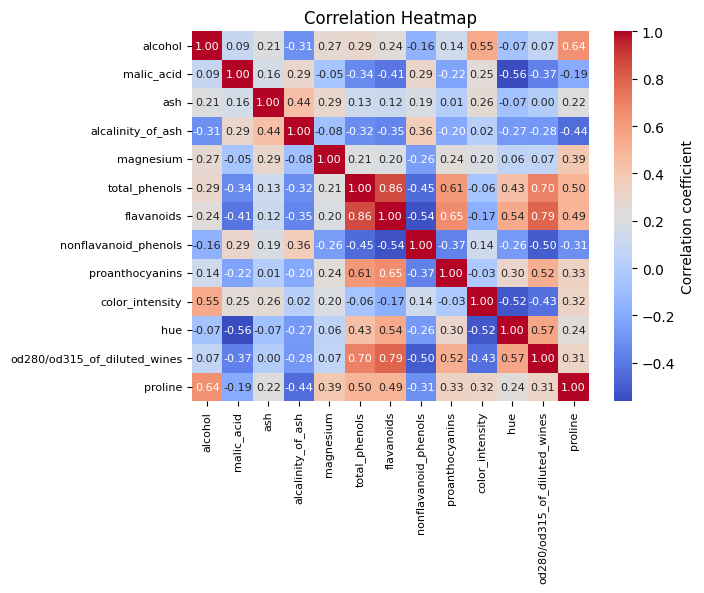

In [5]:
numeric_data = data.select_dtypes(include=['float64', 'int64'])

sns.heatmap(numeric_data.corr(), annot=True, 
             cmap="coolwarm", fmt=".2f", annot_kws={"size": 8}, 
             cbar_kws={'label': 'Correlation coefficient'})
plt.title("Correlation Heatmap")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

Number of outliers in each column: 
alcohol                         0
malic_acid                      3
ash                             3
alcalinity_of_ash               4
magnesium                       4
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 2
color_intensity                 4
hue                             1
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64


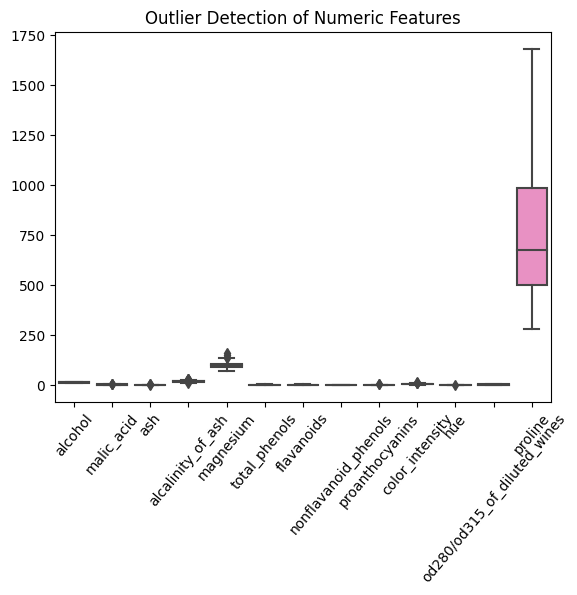

In [7]:
# Outliers
numeric_df = data.select_dtypes(include=['float64', 'int64'])
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).sum()
print(f"Number of outliers in each column: \n{outliers}")

sns.boxplot(data=numeric_df)
plt.title("Outlier Detection of Numeric Features")
plt.xticks(rotation=50)
plt.show()

In [ ]:
## 3. Splitting Data into Training and Test Sets

In [8]:
x = data.drop(columns=['Target'])  
y = data['Target']                 

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}, y_test: {y_test.shape}")

print(x_train.head())
print(x_train.dtypes)

x_train: (142, 13), y_train: (142,)
x_test: (36, 13), y_test: (36,)
     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
158    14.34        1.68  2.70               25.0       98.0           2.80   
137    12.53        5.51  2.64               25.0       96.0           1.79   
98     12.37        1.07  2.10               18.5       88.0           3.52   
159    13.48        1.67  2.64               22.5       89.0           2.60   
38     13.07        1.50  2.10               15.5       98.0           2.40   

     flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
158        1.31                  0.53             2.70            13.00  0.57   
137        0.60                  0.63             1.10             5.00  0.82   
98         3.75                  0.24             1.95             4.50  1.04   
159        1.10                  0.52             2.29            11.75  0.57   
38         2.64                  0.28             1.

## 4. Data Preprocessing

In [9]:
# Handle Outliers by using IQR
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
numerical_columns = x_train.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_columns:
    cap_outliers(x_train, col)
    cap_outliers(x_test, col)

print(f"Preprocessed Training set:\n{x_train.head()}")

Preprocessed Training set:
     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
158    14.34       1.680  2.70               25.0       98.0           2.80   
137    12.53       5.415  2.64               25.0       96.0           1.79   
98     12.37       1.070  2.10               18.5       88.0           3.52   
159    13.48       1.670  2.64               22.5       89.0           2.60   
38     13.07       1.500  2.10               15.5       98.0           2.40   

     flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
158        1.31                  0.53             2.70         10.47625  0.57   
137        0.60                  0.63             1.10          5.00000  0.82   
98         3.75                  0.24             1.95          4.50000  1.04   
159        1.10                  0.52             2.29         10.47625  0.57   
38         2.64                  0.28             1.37          3.70000  1.18   

     od280/

In [10]:
scaler_robust = RobustScaler()
numerical_columns = x_train.select_dtypes(include=['float64', 'int64']).columns
x_train[numerical_columns] = scaler_robust.fit_transform(x_train[numerical_columns])
x_test[numerical_columns] = scaler_robust.transform(x_test[numerical_columns])

print(f"Preprocessed Training set:\n{x_train.head()}")

Preprocessed Training set:
      alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
158  0.988848   -0.128289  1.030303           1.348837   0.000000   
137 -0.356877    2.328947  0.848485           1.348837  -0.106667   
98  -0.475836   -0.529605 -0.787879          -0.162791  -0.533333   
159  0.349442   -0.134868  0.848485           0.767442  -0.480000   
38   0.044610   -0.246711 -0.787879          -0.860465   0.000000   

     total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
158       0.455814   -0.445415                  0.95         1.595819   
137      -0.483721   -0.858806                  1.45        -0.634146   
98        1.125581    0.975255                 -0.50         0.550523   
159       0.269767   -0.567686                  0.90         1.024390   
38        0.083721    0.328967                 -0.30        -0.257840   

     color_intensity       hue  od280/od315_of_diluted_wines   proline  
158         2.024548 -1.170370                

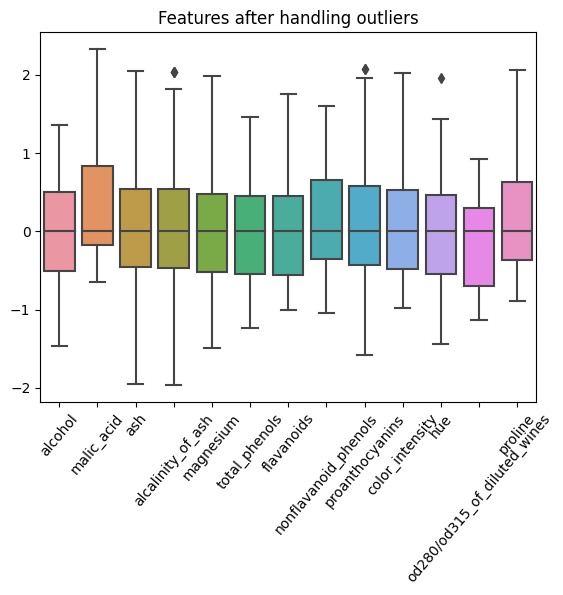

In [11]:
# features after handling outliers
sns.boxplot(data=x_train[numerical_columns])
plt.title("Features after handling outliers")
plt.xticks(rotation=50)
plt.show()

## 5. Model Fitting, Test, Evaluation  

In [12]:
model = AdaBoostClassifier(n_estimators=50, random_state=42)
model.fit(x_train, y_train)
accuracy = model.score(x_test, y_test)
print(f"Accuracy based on test dataset : {accuracy:.2f}")

Accuracy based on test dataset : 0.92


In [14]:
# Predict the labels of the test set
y_pred = model.predict(x_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"AdaBoost Classification Accuracy: {accuracy*100:.2f}%")
for i, j in zip(y_test, y_pred):
    print(f"Actual: {i:0.2f}. Predict: {j:0.2f}")

AdaBoost Classification Accuracy: 91.67%
Actual: 0.00. Predict: 1.00
Actual: 0.00. Predict: 0.00
Actual: 2.00. Predict: 2.00
Actual: 0.00. Predict: 0.00
Actual: 1.00. Predict: 1.00
Actual: 0.00. Predict: 0.00
Actual: 1.00. Predict: 1.00
Actual: 2.00. Predict: 2.00
Actual: 1.00. Predict: 1.00
Actual: 2.00. Predict: 2.00
Actual: 0.00. Predict: 1.00
Actual: 2.00. Predict: 1.00
Actual: 0.00. Predict: 0.00
Actual: 1.00. Predict: 1.00
Actual: 0.00. Predict: 0.00
Actual: 1.00. Predict: 1.00
Actual: 1.00. Predict: 1.00
Actual: 1.00. Predict: 1.00
Actual: 0.00. Predict: 0.00
Actual: 1.00. Predict: 1.00
Actual: 0.00. Predict: 0.00
Actual: 1.00. Predict: 1.00
Actual: 1.00. Predict: 1.00
Actual: 2.00. Predict: 2.00
Actual: 2.00. Predict: 2.00
Actual: 2.00. Predict: 2.00
Actual: 1.00. Predict: 1.00
Actual: 1.00. Predict: 1.00
Actual: 1.00. Predict: 1.00
Actual: 0.00. Predict: 0.00
Actual: 0.00. Predict: 0.00
Actual: 1.00. Predict: 1.00
Actual: 2.00. Predict: 2.00
Actual: 0.00. Predict: 0.00
Actual:

In [17]:
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"{model}. Mean Squared Error: {mse:.2f}")
print(f"{model}. mean_absolute_error: {mae:.2f}")
print(f"{model}. r2_score: {r2:.2f}")

AdaBoostClassifier(random_state=42). Mean Squared Error: 0.08
AdaBoostClassifier(random_state=42). mean_absolute_error: 0.08
AdaBoostClassifier(random_state=42). r2_score: 0.86
